In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import ipywidgets as widgets
import kagglehub

# Enable inline plotting in Google Colab
%matplotlib inline

# Downloading Dataset from Kaggle

In [ ]:
path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

# Exploratory  Analysis on **Amazon Sale Report**

In [ ]:
amazon_df = pd.read_csv(path+'/Amazon Sale Report.csv', index_col=0)

<ipython-input-4-c38349028497>:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  amazon_df = pd.read_csv(path+'/Amazon Sale Report.csv', index_col=0)


In [ ]:
# Set Date column format
amazon_df['Date'] = pd.to_datetime(amazon_df['Date'], format='%m-%d-%y', dayfirst=True, errors='coerce')

In [ ]:
# Dataset Shape
amazon_df.shape

(128975, 23)

In [ ]:
# Dataset Columns
amazon_df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [ ]:
# Dataset Head
amazon_df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# Dataset Info
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128975 non-null  object        
 1   Date                128975 non-null  datetime64[ns]
 2   Status              128975 non-null  object        
 3   Fulfilment          128975 non-null  object        
 4   Sales Channel       128975 non-null  object        
 5   ship-service-level  128975 non-null  object        
 6   Style               128975 non-null  object        
 7   SKU                 128975 non-null  object        
 8   Category            128975 non-null  object        
 9   Size                128975 non-null  object        
 10  ASIN                128975 non-null  object        
 11  Courier Status      122103 non-null  object        
 12  Qty                 128975 non-null  int64         
 13  currency            121180 non-nul

In [ ]:
# Count of unique values
amazon_df.nunique().to_frame(name='Count of unique values')

,Count of unique values
Order ID,120378
Date,91
Status,13
Fulfilment,2
Sales Channel,2
ship-service-level,2
Style,1377
SKU,7195
Category,9
Size,11


In [ ]:
# Unique Values
amazon_df.apply(pd.unique).to_frame(name='Unique Values')

,Unique Values
Order ID,"[405-8078784-5731545, 171-9198151-1101146, 404..."
Date,"[2022-04-30T00:00:00.000000000, 2022-04-29T00:..."
Status,"[Cancelled, Shipped - Delivered to Buyer, Ship..."
Fulfilment,"[Merchant, Amazon]"
Sales Channel,"[Amazon.in, Non-Amazon]"
ship-service-level,"[Standard, Expedited]"
Style,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET..."
SKU,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X..."
Category,"[Set, kurta, Western Dress, Top, Ethnic Dress,..."
Size,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]"


In [ ]:
# Missing Values Count
missing_count = amazon_df.isnull().sum()
missing_count[missing_count > 0]

,0
Courier Status,6872
currency,7795
Amount,7795
ship-city,33
ship-state,33
ship-postal-code,33
ship-country,33
promotion-ids,49153
fulfilled-by,89698
Unnamed: 22,49050


# Cleaning Dataset

In [ ]:
amazon_df.replace('nan', np.nan, inplace=True)

# Remove unnecessary columns due to having only 1 unique value in column
amazon_df.drop(columns=['Unnamed: 22', 'fulfilled-by', 'Sales Channel ', 'ship-country', 'currency'], inplace=True)

# Fill missing values
amazon_df['Courier Status'].fillna('Pending', inplace=True)
# amazon_df['currency'].fillna('INR', inplace=True)
amazon_df[['ship-city', 'ship-state', 'ship-postal-code']].fillna('Unknown', inplace=True)
amazon_df['promotion-ids'].fillna('No Promotion', inplace=True)
amazon_df['Amount'].fillna(amazon_df['Amount'].mean(), inplace=True)  # Fill with mean

# Setting correct data type
amazon_df['ship-postal-code'] = amazon_df['ship-postal-code'].astype(str)

<ipython-input-6-259d1ba1ad70>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  amazon_df['Courier Status'].fillna('Pending', inplace=True)
<ipython-input-6-259d1ba1ad70>:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  amazon_df[['ship-city', 'ship-state', 'ship-postal-code']].fillna('Unknown', inplace=True)
<ipython-input-6-259d1ba1ad70>:9: Sett

In [ ]:
# Save Cleaned Dataset
# Replace any embedded newlines in all object-dtype (text) columns
text_cols = amazon_df.select_dtypes(include=['object']).columns
for col in text_cols:
    # replace any \r or \n into a single space
    amazon_df[col] = amazon_df[col].str.replace(r'[\r\n]+', ' ', regex=True)

amazon_df.to_csv('Cleaned Amazon Sale Report.csv', index=False, quoting=csv.QUOTE_ALL)

# Analysis

In [ ]:
# Descriptive Statistics
amazon_df.describe(include='O')

,Order ID,Status,Fulfilment,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,ship-city,ship-state,ship-postal-code,promotion-ids
count,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,128942,128942,128975,128975
unique,120378,13,2,2,1377,7195,9,11,7190,4,8955,69,9460,5788
top,171-5057375-2831560,Shipped,Amazon,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,BENGALURU,MAHARASHTRA,201301.0,No Promotion
freq,12,77804,89698,88615,4224,773,50284,22711,773,109487,11217,22260,1006,49153


In [ ]:
amazon_df["Qty"]

,Qty
index,
0,0
1,1
2,1
3,0
4,1
...,...
128970,1
128971,1
128972,1


**Sales Rate by Date**

In [ ]:
daily_sales = amazon_df.groupby('Date').agg(total_qty=('Qty', 'sum'), total_amount=('Amount', 'sum')).reset_index()
daily_sales

,Date,total_qty,total_amount
0,2022-03-31,156,1.075209e+05
1,2022-04-01,1319,9.355232e+05
2,2022-04-02,1408,9.773091e+05
3,2022-04-03,1544,1.075971e+06
4,2022-04-04,1331,9.410783e+05
...,...,...,...
86,2022-06-25,940,6.944454e+05
87,2022-06-26,1122,8.086323e+05
88,2022-06-27,1023,7.504441e+05
89,2022-06-28,1104,8.213762e+05


**Sales Trend Over Time**

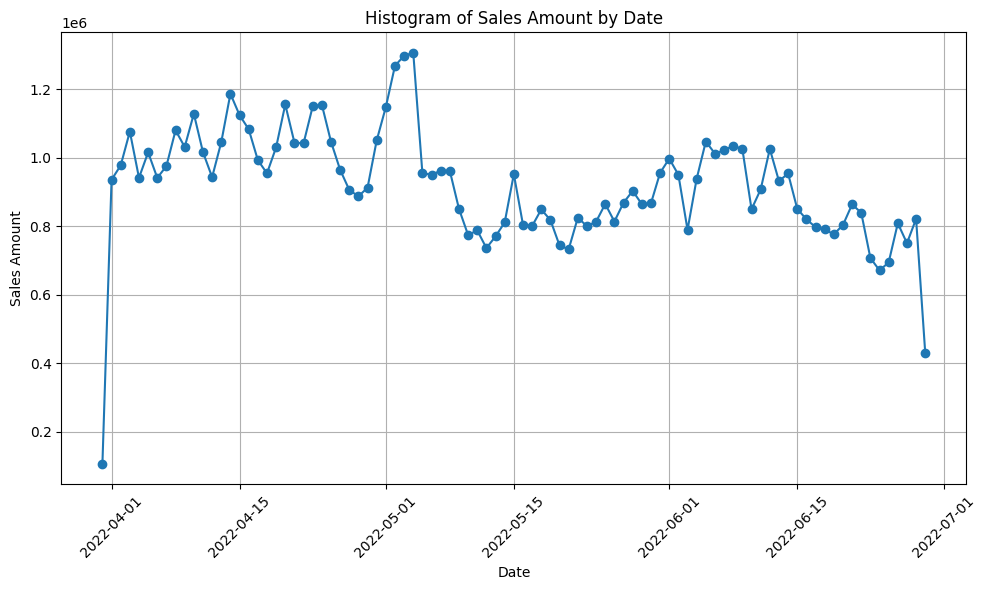

In [ ]:
sales = amazon_df.groupby('Date').sum()
plt.figure(figsize=(10, 6))
plt.plot(sales.index, sales['Amount'], marker='o')
plt.title('Histogram of Sales Amount by Date')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
top_days = daily_sales.sort_values(by='total_amount', ascending=False).head(10)
print(top_days)

         Date  total_qty  total_amount
34 2022-05-04       1811  1.305351e+06
33 2022-05-03       1863  1.297037e+06
32 2022-05-02       1889  1.267666e+06
14 2022-04-14       1695  1.186126e+06
20 2022-04-20       1696  1.154837e+06
24 2022-04-24       1628  1.154474e+06
23 2022-04-23       1665  1.149313e+06
31 2022-05-01       1661  1.147408e+06
10 2022-04-10       1619  1.127768e+06
15 2022-04-15       1620  1.123772e+06


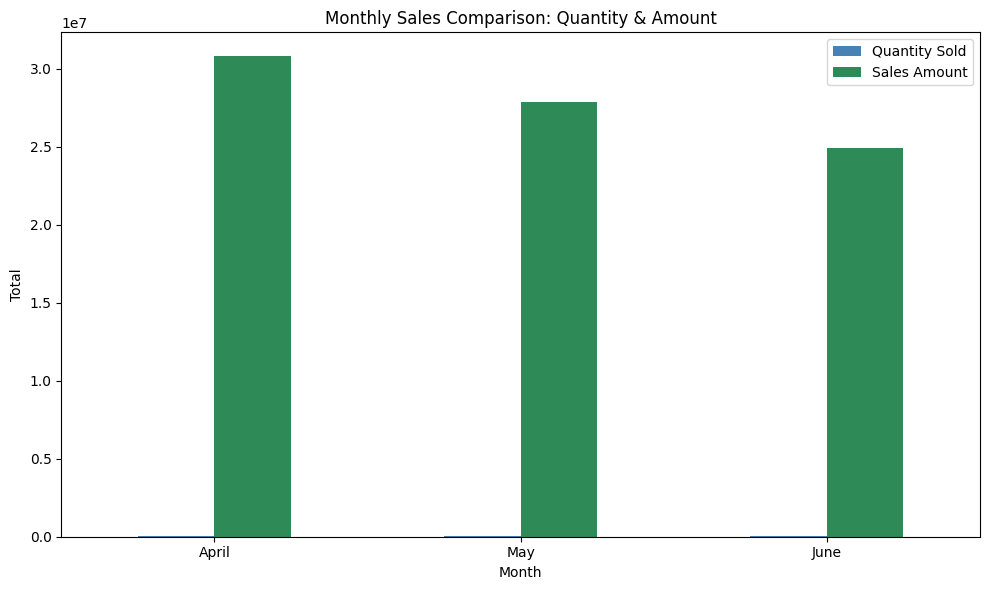

In [ ]:
# Ensure 'Date' column is datetime type
amazon_df['Date'] = pd.to_datetime(amazon_df['Date'])

# Extract month names
amazon_df['Month'] = amazon_df['Date'].dt.month_name()

# Group by month and aggregate Qty and Amount
monthly_summary = amazon_df.groupby('Month')[['Qty', 'Amount']].sum()

# Reorder months to chronological order
ordered_months = ['April', 'May', 'June']
monthly_summary = monthly_summary.loc[ordered_months]

# Plotting
monthly_summary.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'seagreen'])
plt.title('Monthly Sales Comparison: Quantity & Amount')
plt.xlabel('Month')
plt.ylabel('Total')
plt.xticks(rotation=0)
plt.legend(['Quantity Sold', 'Sales Amount'])
plt.tight_layout()
plt.show()

**Sales trend by size and category**

In [ ]:
sales_by_size = amazon_df.groupby('Size')['Amount'].sum().sort_values(ascending=False)
sales_by_size

,Amount
Size,
M,1.482706e+07
L,1.409877e+07
XL,1.321081e+07
S,1.136662e+07
XXL,1.130431e+07
3XL,9.652649e+06
XS,7.583381e+06
6XL,5.976519e+05
5XL,4.407221e+05


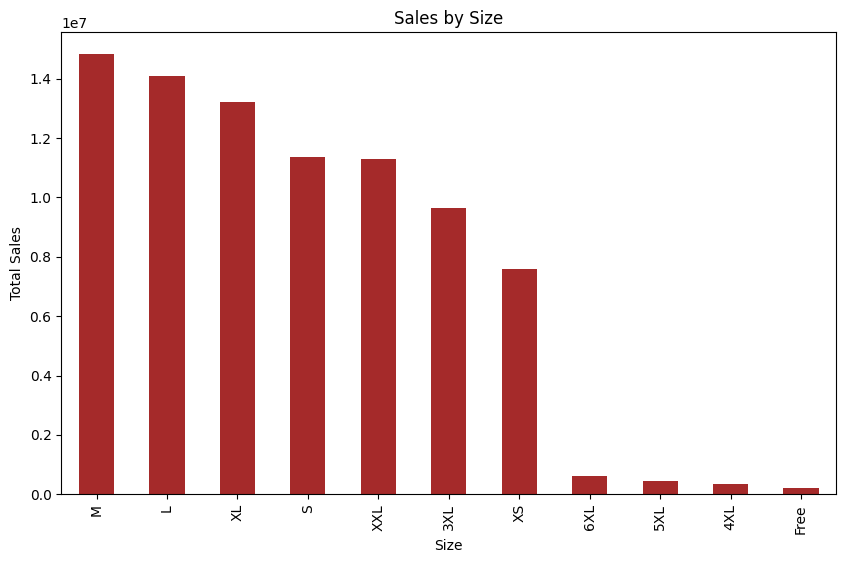

In [ ]:
plt.figure(figsize=(10, 6))
sales_by_size.plot(kind='bar', color='brown')
plt.title('Sales by Size')
plt.xlabel('Size')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
sales_by_category = amazon_df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
sales_by_category

,Amount
Category,
Set,4.130676e+07
kurta,2.334900e+07
Western Dress,1.173233e+07
Top,5.644185e+06
Ethnic Dress,8.340227e+05
Blouse,4.875934e+05
Bottom,1.636392e+05
Saree,1.297708e+05
Dupatta,9.150000e+02


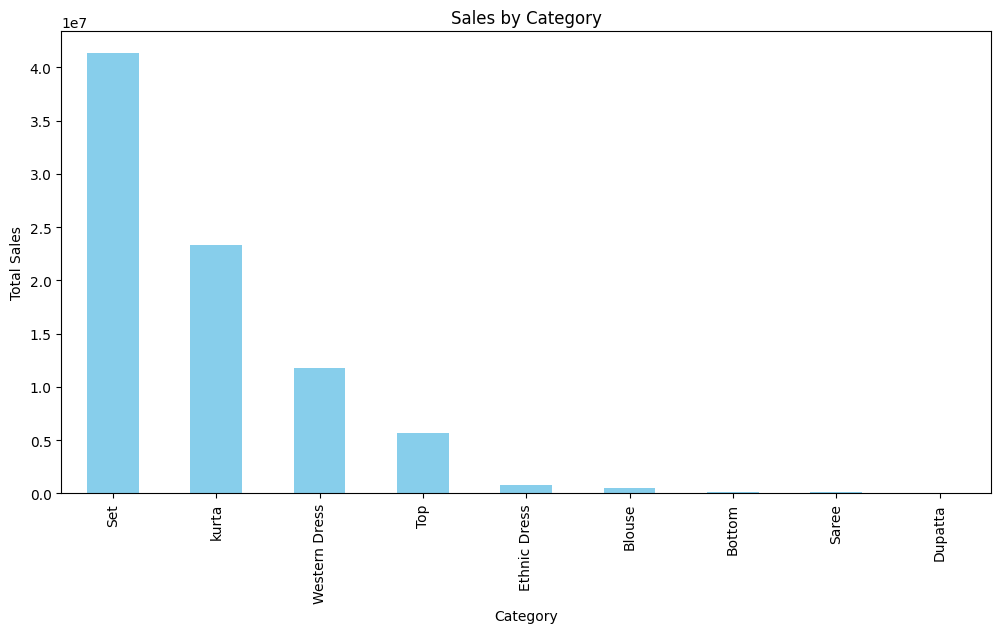

In [ ]:
plt.figure(figsize=(12, 6))
sales_by_category.plot(kind='bar', color='skyblue')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

**Sales Status**

In [ ]:
status_distribution = amazon_df['Status'].value_counts()
status_distribution

,count
Status,
Shipped,77804
Shipped - Delivered to Buyer,28769
Cancelled,18332
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


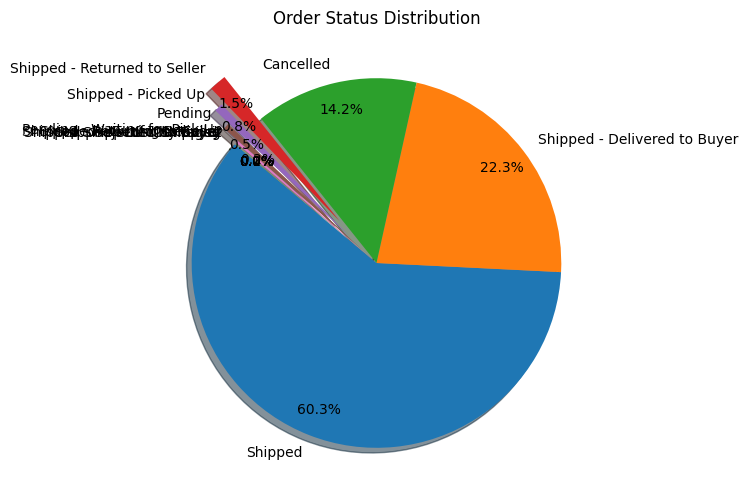

In [ ]:
plt.figure(figsize=(8, 6))
explode = (0, 0, 0, 0.3, 0.2, 0.1, 0, 0, 0, 0, 0, 0, 0)

status_distribution.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    # wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.85,  # Moves percentage labels inward
    labeldistance=1.1,  # Moves labels outward
    explode=explode,
    shadow=True
)
plt.title('Order Status Distribution')
plt.ylabel('')
plt.show()

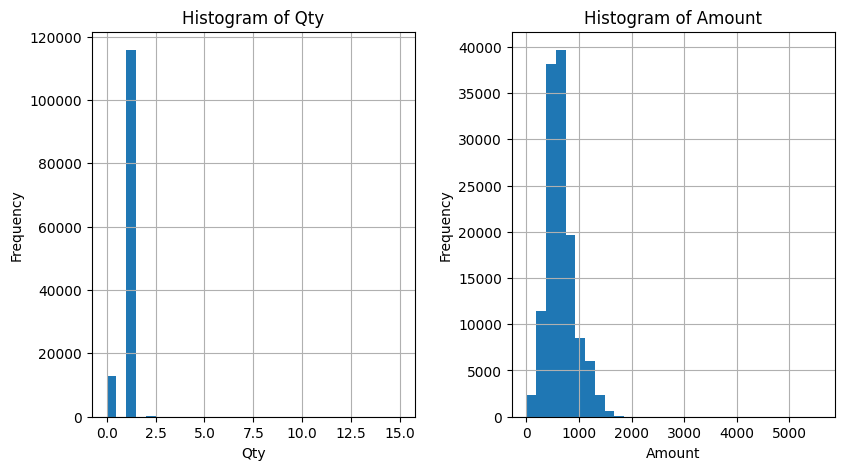

In [ ]:
# Select numeric columns
numeric_cols = amazon_df.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 0:
    num_cols = len(numeric_cols)
    rows = (num_cols // 3) + (num_cols % 3 > 0)  # 3 columns per row

    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
    axes = axes.flatten()

    # Plot Frequencies of different columns
    for i, col in enumerate(numeric_cols):
        amazon_df[col].hist(bins=30, ax=axes[i])
        axes[i].set_title(f"Histogram of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Adds space between plots
    plt.show()


<Axes: >

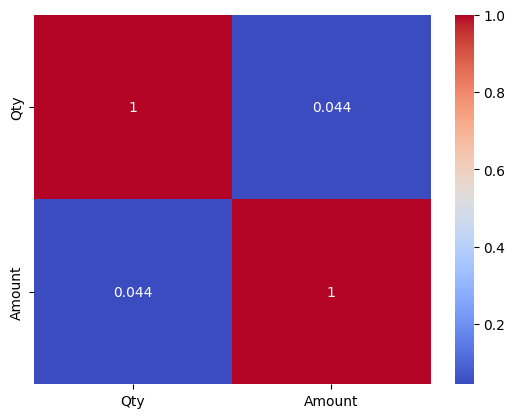

In [ ]:
corr = amazon_df[['Qty', 'Amount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

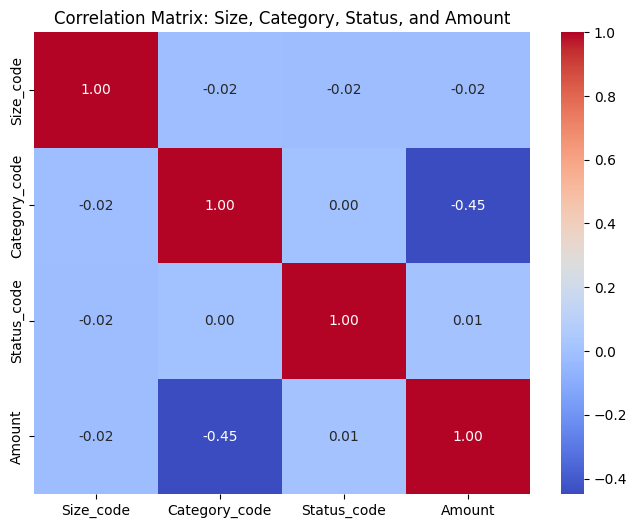

In [ ]:
# Convert categorical columns 'Size', 'Category', 'Status' to numeric codes
amazon_df['Size_code'] = amazon_df['Size'].astype('category').cat.codes
amazon_df['Category_code'] = amazon_df['Category'].astype('category').cat.codes
amazon_df['Status_code'] = amazon_df['Status'].astype('category').cat.codes

# Create a correlation matrix for relevant numeric columns
correlation_matrix = amazon_df[['Size_code', 'Category_code', 'Status_code', 'Amount']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix: Size, Category, Status, and Amount')
plt.show()ٍ

# Interactive Dashboard

## Google Looker Studio

[Dashboard](https://lookerstudio.google.com/reporting/106f6e80-867e-42bb-a002-1008beb855a6)

## Feature Transformation


1.   Scaling numerical features
2.   Log Transformation
3.   Polynomial Features
4.   Binning



In [ ]:
data=df
data

,Order ID,Date,Status,Fulfilment,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Pending,0,647.62,MUMBAI,MAHARASHTRA,400081.0,No Promotion,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Pending,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,No Promotion,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,600073.0,No Promotion,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,517.00,HYDERABAD,TELANGANA,500013.0,No Promotion,False
128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,999.00,GURUGRAM,HARYANA,122004.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False
128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,690.00,HYDERABAD,TELANGANA,500049.0,No Promotion,False
128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Expedited,J0012,J0012-SKD-XS,Set,XS,B0894Y2NJQ,Shipped,1,1199.00,Halol,Gujarat,389350.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False


In [ ]:
scaler = StandardScaler()
data[['Qty', 'Amount']] = scaler.fit_transform(data[['Qty', 'Amount']])

data[['Amount','Qty']]

,Amount,Qty
0,-0.003454,-2.886307
1,-0.889872,0.304989
2,-1.172358,0.304989
3,0.384359,-2.886307
4,-0.273540,0.304989
...,...,...
128970,-0.482652,0.304989
128971,1.285635,0.304989
128972,0.152023,0.304989
128973,2.019364,0.304989


In [ ]:
# Log Transformation

data['Amount_log'] = np.log1p(data['Amount'].abs())    # للتوزيع الغير متماثل , مع عدم فقدان القيم السالبه

data[['Amount_log']]

,Amount_log
0,0.003448
1,0.636509
2,0.775813
3,0.325237
4,0.241800
...,...
128970,0.393833
128971,0.826644
128972,0.141520
128973,1.105046
